In [45]:

# Address the challenge of optimally placing products across warehouses for a business with high online sales, 
# where accurate calculations are costly and only feasible biweekly. To speed up decision-making, 
# an ML model approximates these results within hours. 
# The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. 
# Because the system is dynamic and full of local optima, 
# it requires careful tuning and robust validation to find reliable, near-optimal solutions.
# 

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

-- inputs X ---
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.9994825

In [47]:
df = pd.DataFrame(X, columns=["x1","x2","x3","x4"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)

print(df.head())
print(df.tail())

          x1        x2        x3        x4          y
27  0.577766  0.428772  0.425826  0.249007  -4.025542
24  0.326076  0.472367  0.453192  0.105887  -6.702089
23  0.282138  0.505987  0.530531  0.096302  -7.966775
4   0.124871  0.129770  0.384400  0.287076 -10.069633
21  0.170347  0.756959  0.276520  0.531231 -11.565742
          x1        x2        x3        x4          y
22  0.859657  0.919592  0.206139  0.097797 -26.857786
10  0.957135  0.597644  0.766114  0.776210 -27.316396
18  0.985622  0.666933  0.156783  0.856535 -28.903274
20  0.683486  0.902770  0.335420  0.999483 -29.427091
25  0.948389  0.894513  0.851638  0.552196 -32.625660


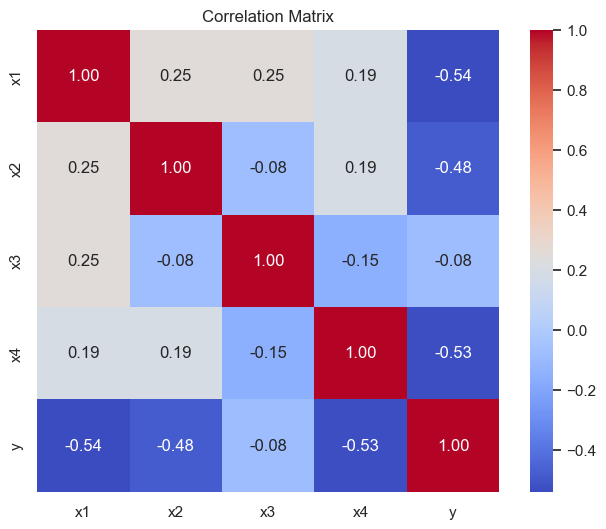

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
# corr = df.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Matrix")
plt.show()

In [49]:
# x1, x2 and x4 have larger negative correlation
# as these value x1, x2 and x4 increase y descreases, i.e. y becomre more negative and moves away from baseline (0 - best result)
# so we have to reduce x1, x2 and x4 values to bring back y to near 0
# x3 has little correlation

In [72]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# kernel = Matern(nu=2.5)
# kernel = C(1.0) * Matern(length_scale=[0.5]*4, nu=2.5)
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5]*4, 
                                      length_scale_bounds=(1e-2, 1e5), 
                                      nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=10)
gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

Optimized Kernel: 2.24**2 * Matern(length_scale=[1.28, 0.904, 1.43, 1.52], nu=2.5)
Training R^2 Score: 0.9777718302891674
Total variance accounted for as noise: 0.1


In [73]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Predict
X_grid = np.random.uniform(0, 1, size=(10000, 4))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()

In [74]:
ei_values = expected_improvement(mu, sigma, y_best, xi=0.01)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {0.01}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")

# best combination so far
#     x1      x2          x3         x4          Y
# 0.577766	0.428772	0.425826	0.249007	-4.025542
# Suggested next: 
#     x1          x2          x3         x4          
#  [0.42550566 0.56541594 0.02100916 0.03443131]
# fixing x1 and x2 to current best value and scan explore x3 and lower x4 bit more 
# as it knows lowering x4 giver better result from the correlation map

expected_improvement with xi: 0.01
Current Best y: -4.025542281908162
Suggested next: [0.48299544 0.40438766 0.18054862 0.27877099]


In [75]:
# kappa = 2.0 is a great starting point for week 1
ucb_values = upper_confidence_bound(mu, sigma, kappa=2.0)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {2.0}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")

UCB Score with kappa: 2.0
Current Best y: -4.025542281908162
Suggested next: [0.42957868 0.40081835 0.06742583 0.1223305 ]


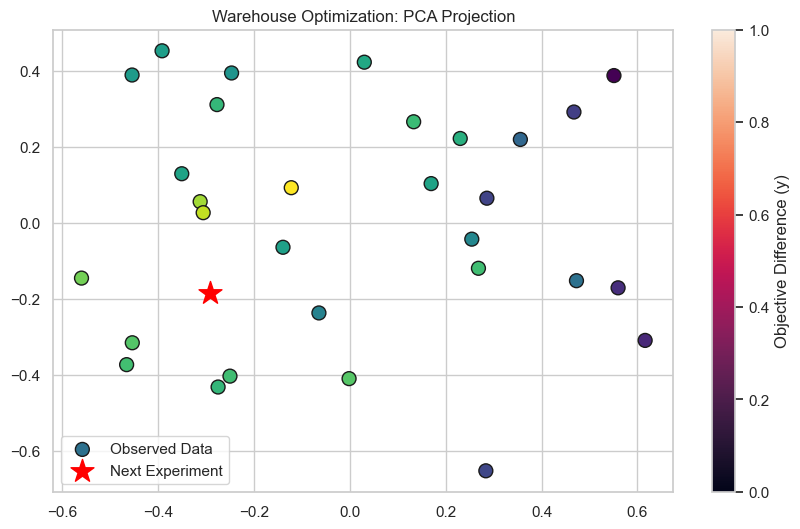

In [76]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
suggested_pca = pca.transform(ucb_next_query.reshape(1, -1))

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=100, edgecolors='k', label='Observed Data')
plt.scatter(suggested_pca[:, 0], suggested_pca[:, 1], c='red', marker='*', s=300, label='Next Experiment')
plt.colorbar(label='Objective Difference (y)')
plt.title('Warehouse Optimization: PCA Projection')
plt.legend()
plt.show()

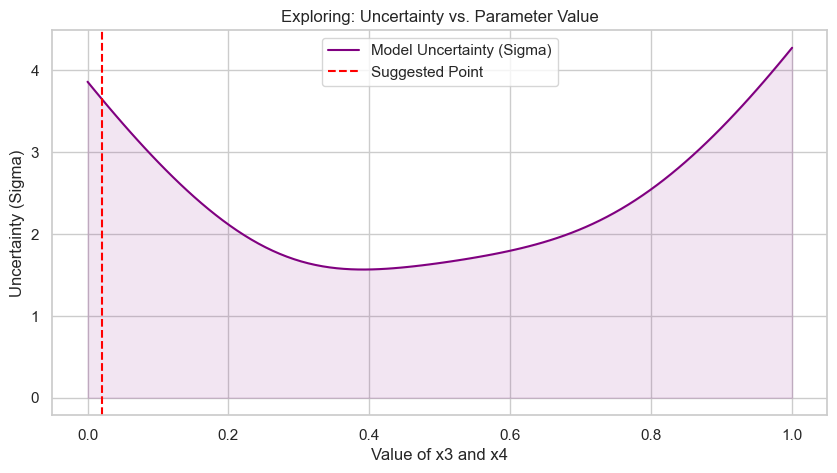

In [77]:
# Create a grid to visualize uncertainty
x_range = np.linspace(0, 1, 100)
# Fix x1 and x2 at the suggested values, vary x3 and x4
X_grid = np.array([[0.42, 0.56, val, val] for val in x_range])

# Predict with the Gaussian Process
_, sigma = gp.predict(X_grid, return_std=True)

plt.figure(figsize=(10, 5))
plt.plot(x_range, sigma, color='purple', label='Model Uncertainty (Sigma)')
plt.axvline(x=0.02, color='red', linestyle='--', label='Suggested Point')
plt.fill_between(x_range, 0, sigma, color='purple', alpha=0.1)
plt.title('Exploring: Uncertainty vs. Parameter Value')
plt.xlabel('Value of x3 and x4')
plt.ylabel('Uncertainty (Sigma)')
plt.legend()
plt.show()

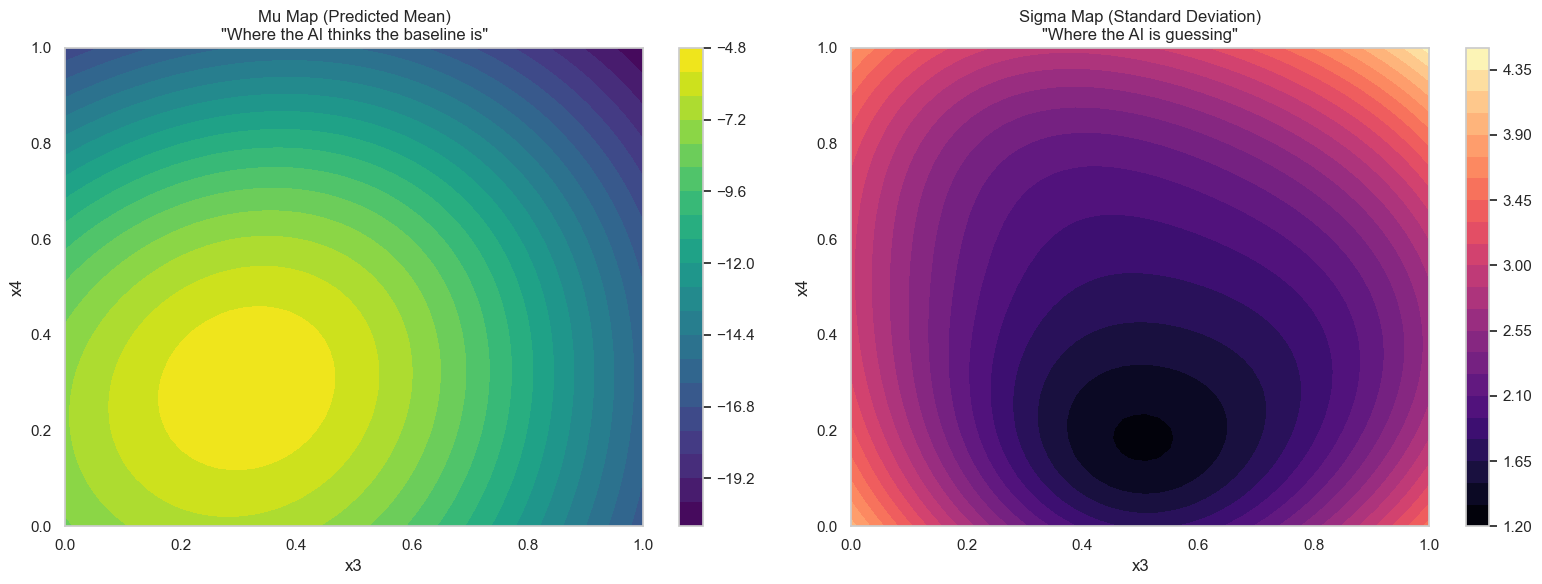

In [81]:
# Create a sweep for x3 and x4 (the parameters the AI wants to change most)
grid_size = 50
x_axis = np.linspace(0, 1, grid_size)
y_axis = np.linspace(0, 1, grid_size)
x3_grid, x4_grid = np.meshgrid(x_axis, y_axis)

# Prepare the 4D input for the GP (holding x1, x2 at suggested values)
# Suggested x1: 0.42, x2: 0.56
# 0.42957868 0.40081835
X_plot = np.zeros((grid_size**2, 4))
X_plot[:, 0] = 0.43
X_plot[:, 1] = 0.40
X_plot[:, 2] = x3_grid.ravel()
X_plot[:, 3] = x4_grid.ravel()

# Predict Mu and Sigma
mu, sigma = gp.predict(X_plot, return_std=True)
mu_grid = mu.reshape(grid_size, grid_size)
sigma_grid = sigma.reshape(grid_size, grid_size)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Map 1: The Mu Map (The Predicted "Truth")
im1 = ax1.contourf(x3_grid, x4_grid, mu_grid, levels=20, cmap='viridis')
ax1.set_title('Mu Map (Predicted Mean)\n"Where the AI thinks the baseline is"')
plt.colorbar(im1, ax=ax1)
ax1.set_xlabel('x3')
ax1.set_ylabel('x4')

# Map 2: The Sigma Map (The Uncertainty)
im2 = ax2.contourf(x3_grid, x4_grid, sigma_grid, levels=20, cmap='magma')
ax2.set_title('Sigma Map (Standard Deviation)\n"Where the AI is guessing"')
plt.colorbar(im2, ax=ax2)
ax2.set_xlabel('x3')
ax2.set_ylabel('x4')

plt.tight_layout()
plt.show()

In [79]:
# # Run this after your PCA fit
# loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=['x1', 'x2', 'x3', 'x4'])
# print(loadings)

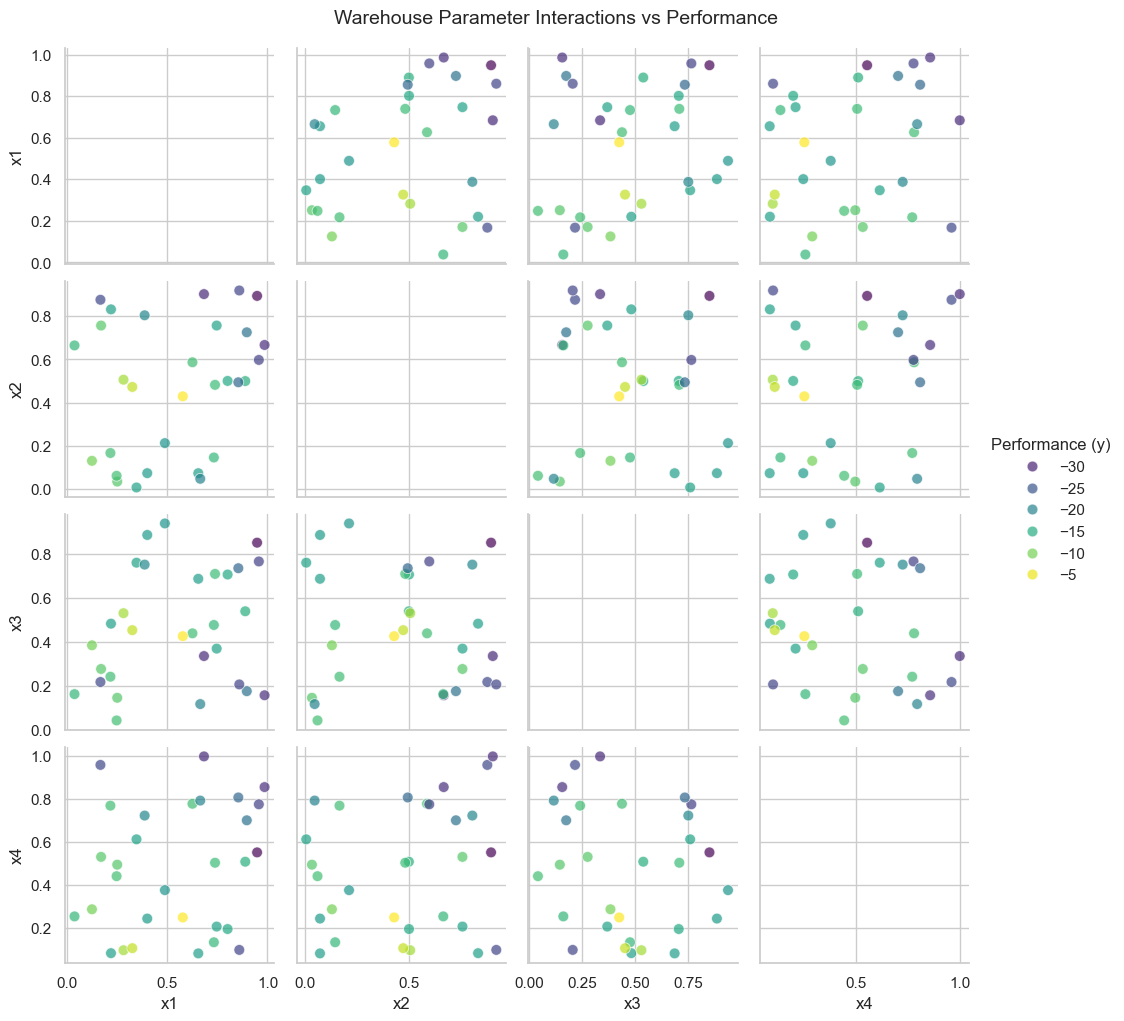

In [80]:
# Pair Plot
import pandas as pd
import seaborn as sns

# Create a simple dataframe
df = pd.DataFrame(X, columns=['x1', 'x2', 'x3', 'x4'])
df['Performance (y)'] = y

sns.set_theme(style="whitegrid")
g = sns.pairplot(
    df, 
    vars=['x1', 'x2', 'x3', 'x4'], 
    hue='Performance (y)', 
    palette='viridis',
    diag_kind='kde', # Shows the density distribution on the diagonal
    plot_kws={'alpha': 0.7, 's': 60}
)

g.fig.suptitle("Warehouse Parameter Interactions vs Performance", y=1.02, fontsize=14)
plt.show()